<a href="https://colab.research.google.com/github/DarkSpartan345/Ciencia-de-datos-Energeticos/blob/main/DemandaEnergetica/Demanda%20Energetica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install pandas
!pip install matplotlib

In [8]:
!pip install pandas openpyxl

In [9]:
!pip install xlrd

In [10]:
!git clone https://github.com/DarkSpartan345/Ciencia-de-datos-Energeticos.git

fatal: destination path 'Ciencia-de-datos-Energeticos' already exists and is not an empty directory.


In [11]:
import pandas as pd
import os

# Carpeta donde están los archivos

años = range(2000, 2026)  # Cambia este rango según los años que tengas

# Lista para almacenar DataFrames
dataframes = []

for año in años:
    archivo = f'/content/Ciencia-de-datos-Energeticos/DemandaEnergetica/Demanda_Energia_SIN_{año}.xlsx'

    try:
        # Leer el archivo (omitiendo las dos primeras filas)
        df = pd.read_excel(archivo, skiprows=3)

        # Guardar en la lista
        dataframes.append(df)

    except FileNotFoundError:
        try:
            # Si no se encuentra el archivo .xlsx, intentar con .xls
            df = pd.read_excel(archivo.replace('.xlsx', '.xls'), skiprows=3)
            dataframes.append(df)
        except FileNotFoundError:
            print(f"Archivo no encontrado: {archivo}")
    except Exception as e:
        print(f"Error leyendo {archivo}: {e}")

# Concatenar todos los DataFrames
df_total = pd.concat(dataframes, ignore_index=True)

# Mostrar resumen
print(df_total.info())
print(df_total.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9332 entries, 0 to 9331
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Fecha                    9332 non-null   object 
 1   Demanda Energia SIN kWh  9332 non-null   float64
 2   Generación kWh           9330 non-null   float64
 3   Demanda No Atendida kWh  8814 non-null   float64
 4   Exportaciones kWh        7771 non-null   float64
 5   Importaciones kWh        6238 non-null   float64
dtypes: float64(5), object(1)
memory usage: 437.6+ KB
None
        Fecha  Demanda Energia SIN kWh  Generación kWh  \
0  2000-01-01             8.814187e+07    8.792426e+07   
1  2000-01-02             8.912437e+07    8.875371e+07   
2  2000-01-03             1.061863e+08    1.058838e+08   
3  2000-01-04             1.095546e+08    1.092070e+08   
4  2000-01-05             1.093482e+08    1.090693e+08   

   Demanda No Atendida kWh  Exportaciones kWh  Importa

In [12]:
DF = df_total.iloc[:, :2]
DF.columns = ['Fecha', 'Demanda Total (kWh)']
DF.head(1000)

,Fecha,Demanda Total (kWh)
0,2000-01-01,8.814187e+07
1,2000-01-02,8.912437e+07
2,2000-01-03,1.061863e+08
3,2000-01-04,1.095546e+08
4,2000-01-05,1.093482e+08
...,...,...
995,2002-09-22,1.101571e+08
996,2002-09-23,1.313407e+08
997,2002-09-24,1.312276e+08
998,2002-09-25,1.297427e+08


In [13]:
DF['Fecha'] = pd.to_datetime(DF['Fecha'], errors='coerce')
DF = DF.sort_values(by='Fecha')
df_mensual = DF.groupby(pd.Grouper(key='Fecha', freq='ME')).sum(numeric_only=True).reset_index()
df_mensual = df_mensual.iloc[:-1]
df_mensual.head(400)

,Fecha,Demanda Total (kWh)
0,2000-01-31,3.354237e+09
1,2000-02-29,3.278267e+09
2,2000-03-31,3.495203e+09
3,2000-04-30,3.298386e+09
4,2000-05-31,3.502127e+09
...,...,...
301,2025-02-28,6.392576e+09
302,2025-03-31,7.051482e+09
303,2025-04-30,6.762015e+09
304,2025-05-31,7.099986e+09


In [14]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_demanda_energetica(df, fecha_col='Fecha', demanda_col='Demanda Total (MWh)', titulo='Demanda energética total - Semestre'):
    """
    Grafica la demanda energética total a lo largo del tiempo.

    Parámetros:
    - df: DataFrame con al menos una columna de fechas y otra con la demanda total
    - fecha_col: nombre de la columna que contiene las fechas
    - demanda_col: nombre de la columna con la demanda total
    - titulo: título del gráfico

    Retorna:
    - None (muestra el gráfico)
    """
    # Asegurar formato datetime para la columna de fecha
    df[fecha_col] = pd.to_datetime(df[fecha_col], errors='coerce')

    # Ordenar por fecha
    df = df.sort_values(by=fecha_col)

    # Crear figura
    plt.figure(figsize=(12, 6))
    plt.plot(df[fecha_col], df[demanda_col], marker='o', linestyle='-', color='steelblue')

    # Formato del gráfico
    plt.title(titulo)
    plt.xlabel('Fecha')
    plt.ylabel('Demanda Total (kWh)')
    plt.grid(True)
    plt.tight_layout()
    plt.xticks(rotation=45)

    # Mostrar gráfico
    plt.show()


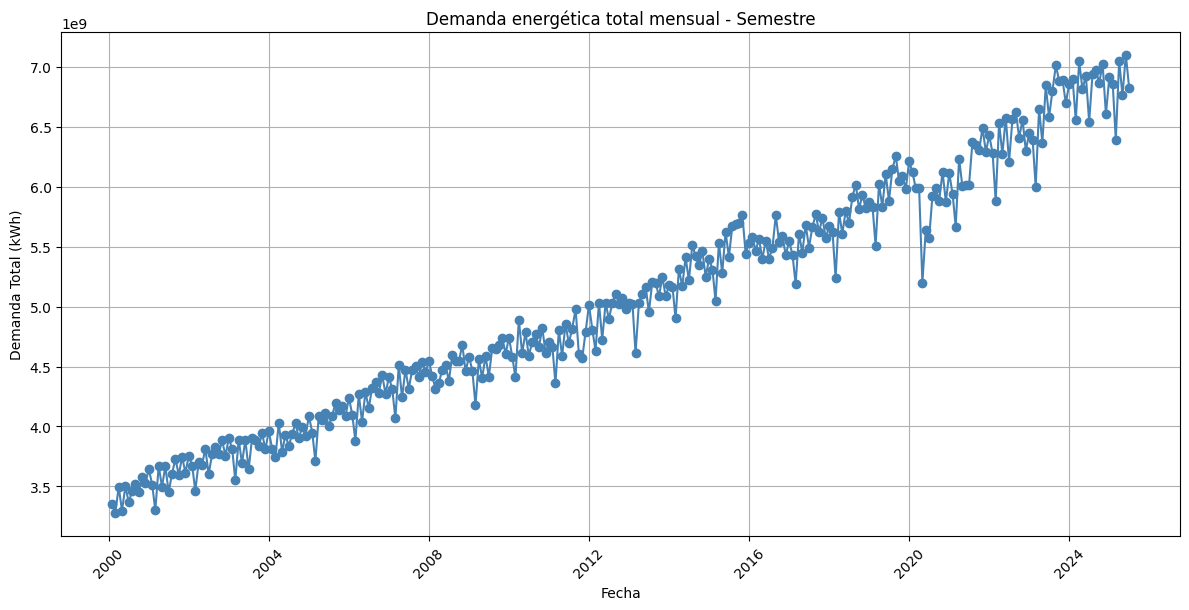

In [15]:
plot_demanda_energetica(df_mensual,titulo='Demanda energética total mensual - Semestre',demanda_col='Demanda Total (kWh)')